trie par insertion {'list_100': 0.0002336740493774414, 'list_1000': 0.028261876106262206, 'list_10000': 2.9149441480636598, 'list_100000': 328.26862955093384}
trie par selection {'list_100': 0.00014073848724365233, 'list_1000': 0.023971986770629884, 'list_10000': 2.5359793186187742, 'list_100000': 348.57402873039246}
trie par bubble {'list_100': 0.0004152059555053711, 'list_1000': 0.054262733459472655, 'list_10000': 6.283390283584595, 'list_100000': 672.7622878551483}
trie par fusion {'list_100': 0.0002806663513183594, 'list_1000': 0.0013708829879760741, 'list_10000': 0.016223454475402833, 'list_100000': 0.3263883113861084}
trie par tas {'list_100': 0.0002356290817260742, 'list_1000': 0.0028991460800170898, 'list_10000': 0.04377777576446533, 'list_100000': 0.548597264289856}
recherche dichotomie {'list_100': 7.755756378173828e-05, 'list_1000': 2.5987625122070313e-06, 'list_10000': 7.2479248046875e-06, 'list_100000': 1.9598007202148438e-05}
temps total de programe :  1483.4232699871063


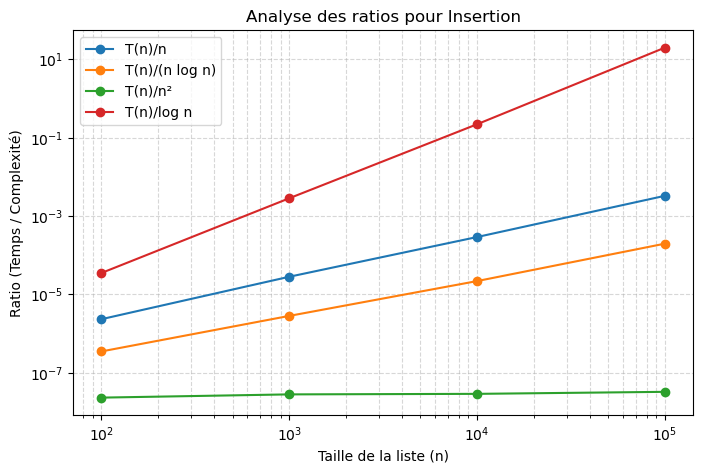

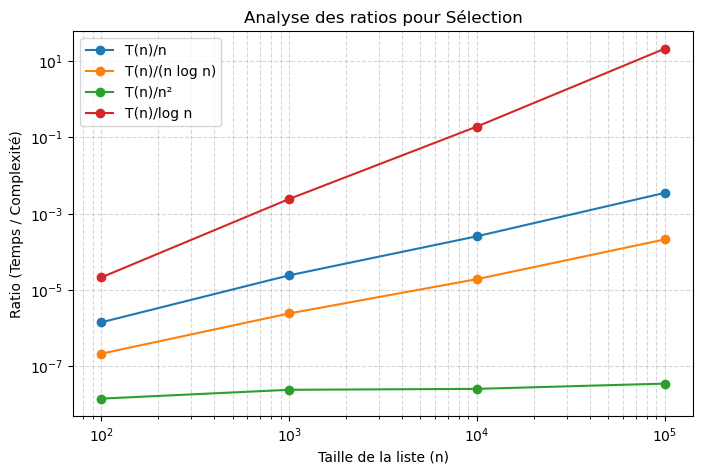

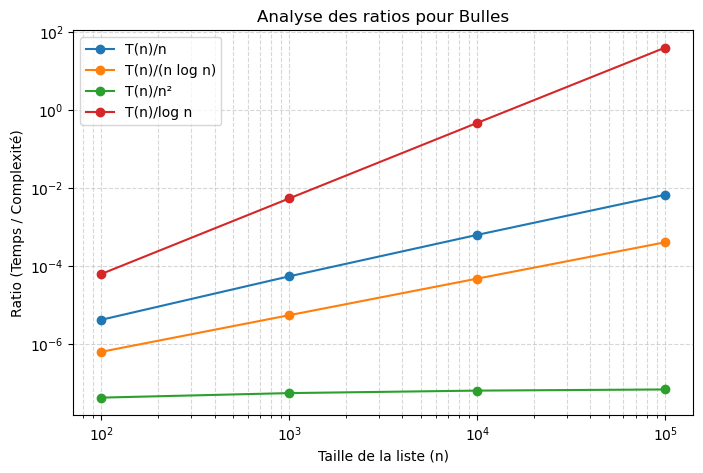

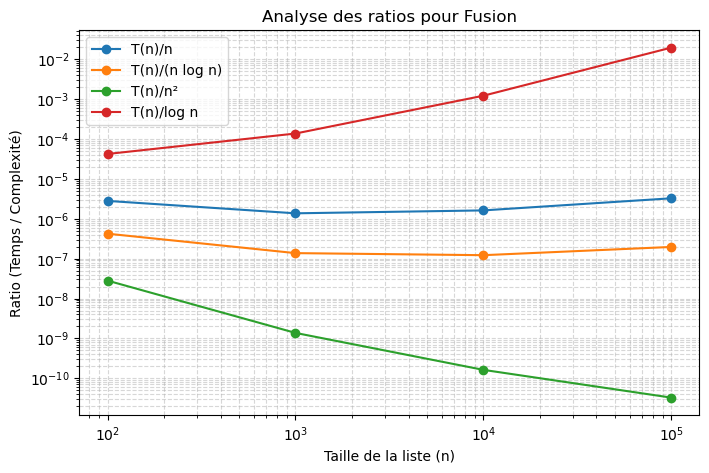

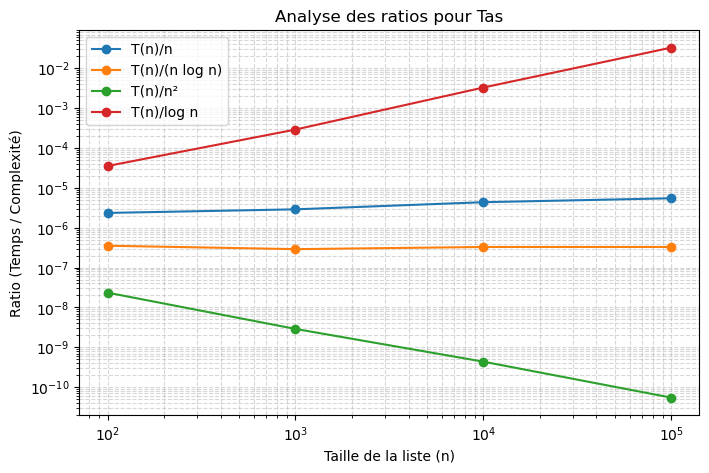

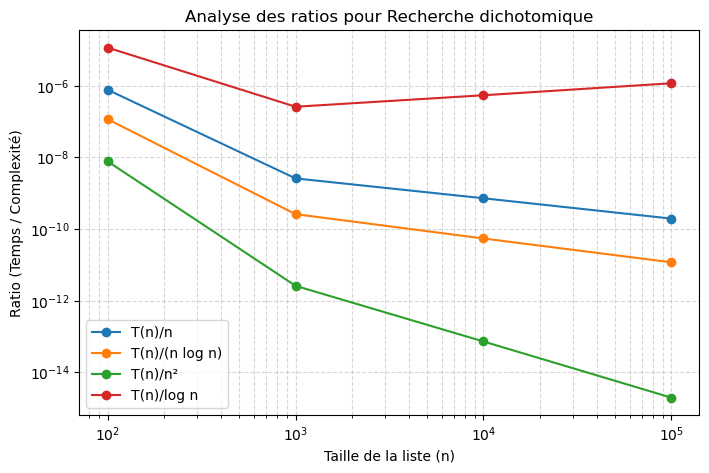

In [1]:

#Le temps d’exécution de ce code est d’environ 24 minutes.


import time 
import random
import matplotlib.pyplot as plt
import numpy as np

def recherche_dichotomique(tableau, valeur):
    debut = 0
    fin = len(tableau) - 1

    while debut <= fin:
        milieu = (debut + fin) // 2

        if tableau[milieu] == valeur:
            return milieu  # position trouvée
        elif tableau[milieu] < valeur:
            debut = milieu + 1
        else:
            fin = milieu - 1

    return -1  # valeur non trouvée


def entasser(tableau, n, i):
    plus_grand = i        
    gauche = 2 * i + 1   
    droite = 2 * i + 2   

    if gauche < n and tableau[gauche] > tableau[plus_grand]:
        plus_grand = gauche

    if droite < n and tableau[droite] > tableau[plus_grand]:
        plus_grand = droite

    if plus_grand != i:
        tableau[i], tableau[plus_grand] = tableau[plus_grand], tableau[i]
        entasser(tableau, n, plus_grand)


def tri_par_tas(tableau):
    n = len(tableau)

    for i in range(n // 2 - 1, -1, -1):
        entasser(tableau, n, i)

    for i in range(n - 1, 0, -1):
        tableau[i], tableau[0] = tableau[0], tableau[i] 
        entasser(tableau, i, 0)

def merge_sort(arr):
    if len(arr) > 1:
        mid = len(arr) // 2
        left_half = arr[:mid]
        right_half = arr[mid:]

        merge_sort(left_half)
        merge_sort(right_half)

        i = j = k = 0
        
        while i < len(left_half) and j < len(right_half):
            if left_half[i] < right_half[j]:
                arr[k] = left_half[i]
                i += 1
            else:
                arr[k] = right_half[j]
                j += 1
            k += 1

        while i < len(left_half):
            arr[k] = left_half[i]
            i += 1
            k += 1

        while j < len(right_half):
            arr[k] = right_half[j]
            j += 1
            k += 1



def bubble_sort(arr):
    n = len(arr)
    for i in range(n - 1):
        swapped = False

        for j in range(0, n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                swapped = True

        if not swapped:
            break
            
def selection_sort(arr):
    n = len(arr)
    for i in range(n):
        min_index = i 
        for j in range(i + 1, n):
            if arr[j] < arr[min_index]:
                min_index = j
        arr[i], arr[min_index] = arr[min_index], arr[i]

def insertion_sort(arr):
    for i in range(1, len(arr)):
        key = arr[i]  
        j = i - 1
        while j >= 0 and arr[j] > key:
            arr[j + 1] = arr[j]
            j -= 1

        arr[j + 1] = key 

t_total1 = time.time()
#insert sort 
tmoy_insert={}

t=[]
for i in range(10):
    n = [random.randint(1, 1000) for i in range(100)]
    t1 = time.time()
    insertion_sort(n)
    t2 = time.time()
    t.append(t2-t1)

tmoy_insert["list_100"] = (sum(t) / len(t))
t=[]
for i in range(10):
    n = [random.randint(1, 10000) for i in range(1000)]
    t1 = time.time()
    insertion_sort(n)
    t2 = time.time()
    t.append(t2-t1)

tmoy_insert["list_1000"] = (sum(t) / len(t))
t=[]
for i in range(10):
    n = [random.randint(1, 100000) for i in range(10000)]
    t1 = time.time()
    insertion_sort(n)
    t2 = time.time()
    t.append(t2-t1)

tmoy_insert["list_10000"] = (sum(t) / len(t))
t=[]
for i in range(1): #juste 1 iteration m'a pris 2.5 minute 
    n = [random.randint(1, 1000000) for i in range(100000)]
    t1 = time.time()
    insertion_sort(n)
    t2 = time.time()
    t.append(t2-t1)

tmoy_insert["list_100000"] = (sum(t) / len(t))



#selection sort 
tmoy_select={}

t=[]
for i in range(10):
    n = [random.randint(1, 1000) for i in range(100)]
    t1 = time.time()
    selection_sort(n)
    t2 = time.time()
    t.append(t2-t1)

tmoy_select["list_100"] = (sum(t) / len(t))
t=[]
for i in range(10):
    n = [random.randint(1, 10000) for i in range(1000)]
    t1 = time.time()
    selection_sort(n)
    t2 = time.time()
    t.append(t2-t1)

tmoy_select["list_1000"] = (sum(t) / len(t))
t=[]
for i in range(10):
    n = [random.randint(1, 100000) for i in range(10000)]
    t1 = time.time()
    selection_sort(n)
    t2 = time.time()
    t.append(t2-t1)

tmoy_select["list_10000"] = (sum(t) / len(t))
t=[]
for i in range(1): #juste 1 iteration m'a pris 2.5 minute 
    n = [random.randint(1, 1000000) for i in range(100000)]
    t1 = time.time()
    selection_sort(n)
    t2 = time.time()
    t.append(t2-t1)

tmoy_select["list_100000"] = (sum(t) / len(t))

#buble sort 
tmoy_buble={}

t=[]
for i in range(10):
    n = [random.randint(1, 1000) for i in range(100)]
    t1 = time.time()
    bubble_sort(n)
    t2 = time.time()
    t.append(t2-t1)

tmoy_buble["list_100"] = (sum(t) / len(t))
t=[]
for i in range(10):
    n = [random.randint(1, 10000) for i in range(1000)]
    t1 = time.time()
    bubble_sort(n)
    t2 = time.time()
    t.append(t2-t1)

tmoy_buble["list_1000"] = (sum(t) / len(t))
t=[]
for i in range(10):
    n = [random.randint(1, 100000) for i in range(10000)]
    t1 = time.time()
    bubble_sort(n)
    t2 = time.time()
    t.append(t2-t1)

tmoy_buble["list_10000"] = (sum(t) / len(t))
t=[]
for i in range(1): #juste 1 iteration m'a pris 3 minute 
    n = [random.randint(1, 1000000) for i in range(100000)]
    t1 = time.time()
    bubble_sort(n)
    t2 = time.time()
    t.append(t2-t1)

tmoy_buble["list_100000"] = (sum(t) / len(t))

#fusion sort
tmoy_fusion={}

t=[]
for i in range(10):
    n = [random.randint(1, 1000) for i in range(100)]
    t1 = time.time()
    merge_sort(n)
    t2 = time.time()
    t.append(t2-t1)

tmoy_fusion["list_100"] = (sum(t) / len(t))
t=[]
for i in range(10):
    n = [random.randint(1, 10000) for i in range(1000)]
    t1 = time.time()
    merge_sort(n)
    t2 = time.time()
    t.append(t2-t1)

tmoy_fusion["list_1000"] = (sum(t) / len(t))
t=[]
for i in range(10):
    n = [random.randint(1, 100000) for i in range(10000)]
    t1 = time.time()
    merge_sort(n)
    t2 = time.time()
    t.append(t2-t1)

tmoy_fusion["list_10000"] = (sum(t) / len(t))
t=[]
for i in range(10):
    n = [random.randint(1, 1000000) for i in range(100000)]
    t1 = time.time()
    merge_sort(n)
    t2 = time.time()
    t.append(t2-t1)

tmoy_fusion["list_100000"] = (sum(t) / len(t))

#tas sort
tmoy_tas={}

t=[]
for i in range(10):
    n = [random.randint(1, 1000) for i in range(100)]
    t1 = time.time()
    tri_par_tas(n)
    t2 = time.time()
    t.append(t2-t1)

tmoy_tas["list_100"] = (sum(t) / len(t))
t=[]
for i in range(10):
    n = [random.randint(1, 10000) for i in range(1000)]
    t1 = time.time()
    tri_par_tas(n)
    t2 = time.time()
    t.append(t2-t1)

tmoy_tas["list_1000"] = (sum(t) / len(t))
t=[]
for i in range(10):
    n = [random.randint(1, 100000) for i in range(10000)]
    t1 = time.time()
    tri_par_tas(n)
    t2 = time.time()
    t.append(t2-t1)

tmoy_tas["list_10000"] = (sum(t) / len(t))
t=[]
for i in range(10):
    n = [random.randint(1, 1000000) for i in range(100000)]
    t1 = time.time()
    tri_par_tas(n)
    t2 = time.time()
    t.append(t2-t1)

tmoy_tas["list_100000"] = (sum(t) / len(t))

#recherche dicotomie
tmoy_recherche={}

t=[]
for i in range(10):
    n = [random.randint(1, 1000) for i in range(100)]
    merge_sort(n)
    t1 = time.time()
    recherche_dichotomique(n,random.randint(1, 1000))
    t2 = time.time()
    t.append(t2-t1)

tmoy_recherche["list_100"] = (sum(t) / len(t))
t=[]
for i in range(10):
    n = [random.randint(1, 10000) for i in range(1000)]
    merge_sort(n)
    t1 = time.time()
    recherche_dichotomique(n,random.randint(1, 10000))
    t2 = time.time()
    t.append(t2-t1)

tmoy_recherche["list_1000"] = (sum(t) / len(t))
t=[]
for i in range(10):
    n = [random.randint(1, 100000) for i in range(10000)]
    merge_sort(n)
    t1 = time.time()
    recherche_dichotomique(n,random.randint(1, 100000))
    t2 = time.time()
    t.append(t2-t1)

tmoy_recherche["list_10000"] = (sum(t) / len(t))
t=[]
for i in range(10):
    n = [random.randint(1, 1000000) for i in range(100000)]
    merge_sort(n)
    t1 = time.time()
    recherche_dichotomique(n,random.randint(1, 1000000))
    t2 = time.time()
    t.append(t2-t1)

tmoy_recherche["list_100000"] = (sum(t) / len(t))

t_total2 = time.time()

print("trie par insertion",tmoy_insert)
print("trie par selection",tmoy_select)
print("trie par bubble",tmoy_buble)
print("trie par fusion",tmoy_fusion)
print("trie par tas",tmoy_tas)
print("recherche dichotomie",tmoy_recherche)
print("temps total de programe : " , t_total2-t_total1)
    

algos = {
    "Insertion": tmoy_insert,
    "Sélection": tmoy_select,
    "Bulles": tmoy_buble,
    "Fusion": tmoy_fusion,
    "Tas": tmoy_tas,
    "Recherche dichotomique": tmoy_recherche
}


sizes = np.array([100, 1000, 10000, 100000], dtype=float)
log_n = np.log2(sizes)

def plot_ratios_with_logn(algo_name, data_dict):
    y = np.array([data_dict[f"list_{int(n)}"] for n in sizes])

    # Ratios pour les complexités candidates
    ratios = {
        "T(n)/n": y / sizes,
        "T(n)/(n log n)": y / (sizes * log_n),
        "T(n)/n²": y / (sizes**2),
        "T(n)/log n": y / log_n
    }

    plt.figure(figsize=(8,5))
    for label, ratio in ratios.items():
        plt.plot(sizes, ratio, 'o-', label=label)

    plt.title(f"Analyse des ratios pour {algo_name}")
    plt.xlabel("Taille de la liste (n)")
    plt.ylabel("Ratio (Temps / Complexité)")
    plt.xscale("log")
    plt.yscale("log")
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend()
    plt.show()

# --- Exécution ---
for nom, dico in algos.items():
    plot_ratios_with_logn(nom, dico)